In [1]:
import matplotlib.pyplot as plt
plt.rcParams['figure.constrained_layout.use'] = True
import pandas as pd
import seaborn as sns

In [2]:
lnums = [4, 8, 12]
top_k = 5
train_ratio = 0.8
a = 0.25
gamma = 0.1
save_dir = "../outputs/"

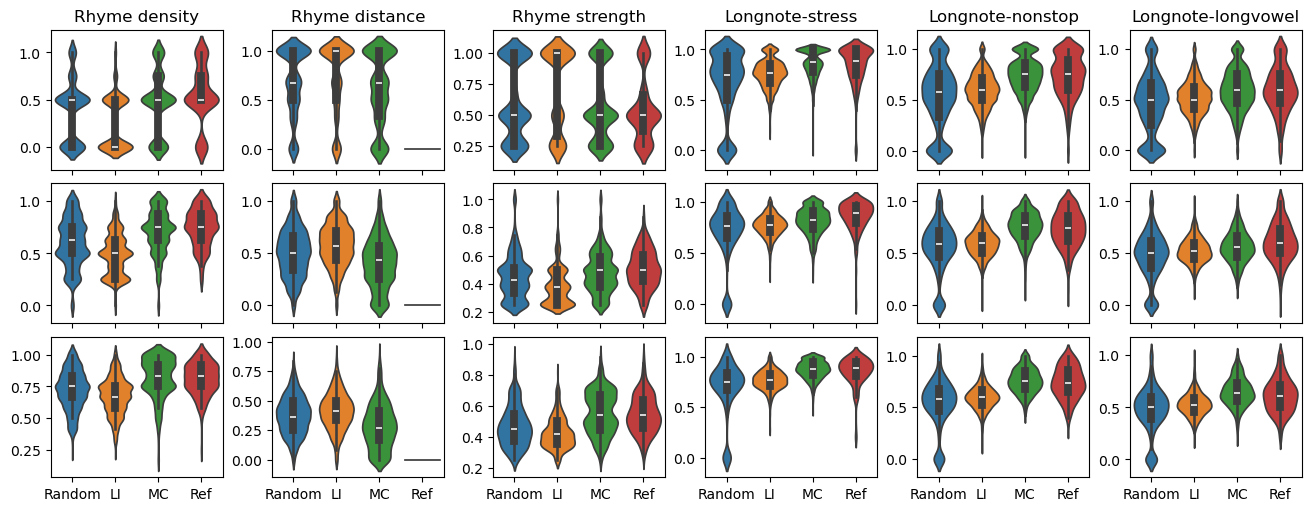

In [3]:
row = 0
fig, ax = plt.subplots(figsize=(13, 5), nrows=3, ncols=6, sharex=True)

for seg_lnum in lnums:
    df_propose = pd.read_csv(f'{save_dir}eval_metrics_mlmcal_seg{seg_lnum}_top{top_k}_gamma{str(gamma)}_a{str(a)}.csv')
    df_len = pd.read_csv(f'{save_dir}metrics_lengthInform_seg{seg_lnum}_top{top_k}.csv')
    df_truth = pd.read_csv(f'{save_dir}metrics_reference_seg{seg_lnum}_top{top_k}.csv')
    df_random = pd.read_csv(f'{save_dir}metrics_random_seg{seg_lnum}_top{top_k}.csv')

    df_propose['method'] = ['MC'] * len(df_propose)
    df_len['method'] = ['LI'] * len(df_len)
    df_truth['method'] = ['Ref'] * len(df_truth)
    df_random['method'] = ['Random'] * len(df_random)
    df_all = pd.concat([df_random, df_len, df_propose, df_truth], axis=0, ignore_index=True)

    # violin plot of each metrics in the dictionary
    df_all.columns = df_all.columns.str.capitalize()
    keys = list(df_all.keys())
    keys.remove('Method')
    keys.remove('Multi-notes')
    keys.remove('Multi-sylphones')

    for k in range(len(keys)):
        sns.violinplot(x="Method", data=df_all, y=keys[k], hue="Method", ax=ax[row, k])
        ax[row, k].set_xlabel('')
        ax[row, k].set_ylabel('')
        if row == 0:
            ax[row, k].set_title(keys[k])

    row += 1

plt.savefig(f'{save_dir}metrics_all_top{top_k}.pdf')

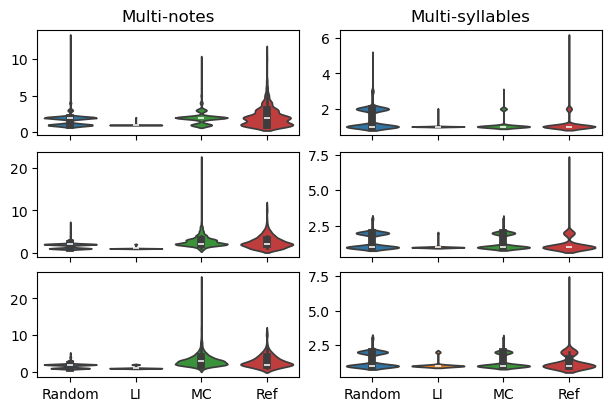

In [9]:
row = 0
fig, ax = plt.subplots(figsize=(6, 4), nrows=3, ncols=2, sharex=True)

for seg_lnum in lnums:
    df_propose = pd.read_csv(f'{save_dir}eval_metrics_mlmcal_seg{seg_lnum}_top{top_k}_gamma{str(gamma)}_a{str(a)}.csv')
    df_len = pd.read_csv(f'{save_dir}metrics_lengthInform_seg{seg_lnum}_top{top_k}.csv')
    df_truth = pd.read_csv(f'{save_dir}metrics_reference_seg{seg_lnum}_top{top_k}.csv')
    df_random = pd.read_csv(f'{save_dir}metrics_random_seg{seg_lnum}_top{top_k}.csv')

    df_propose['method'] = ['MC'] * len(df_propose)
    df_len['method'] = ['LI'] * len(df_len)
    df_truth['method'] = ['Ref'] * len(df_truth)
    df_random['method'] = ['Random'] * len(df_random)
    df_all = pd.concat([df_random, df_len, df_propose, df_truth], axis=0, ignore_index=True)

    # violin plot of each metrics in the dictionary
    df_all.rename(columns={"multi-sylphones": "multi-syllables"}, inplace=True)
    df_all.columns = df_all.columns.str.capitalize()
    keys = list(df_all.keys())
    keys.remove('Method')
    keys.remove('Rhyme density')
    keys.remove('Rhyme strength')
    keys.remove('Rhyme distance')
    keys.remove('Longnote-stress')
    keys.remove('Longnote-nonstop')
    keys.remove('Longnote-longvowel')


    for k in range(len(keys)):
        sns.violinplot(x="Method", data=df_all, y=keys[k], hue="Method", ax=ax[row, k])
        ax[row, k].set_xlabel('')
        ax[row, k].set_ylabel('')
        if row == 0:
            ax[row, k].set_title(keys[k])

    row += 1

plt.savefig(f'{save_dir}metrics_extremeMatches_top{top_k}.pdf')

In [8]:
df_all

,Multi-notes,Multi-sylphones,Rhyme density,Rhyme distance,Rhyme strength,Longnote-stress,Longnote-nonstop,Longnote-longvowel,Method
0,2,1,0.833333,0.090909,0.754167,0.727273,0.454545,0.818182,Random
1,2,1,0.666667,0.416667,0.312500,0.833333,0.633333,0.633333,Random
2,2,1,0.750000,0.333333,0.319444,0.708333,0.750000,0.500000,Random
3,2,1,1.000000,0.083333,0.916667,0.781250,0.656250,0.687500,Random
4,2,1,0.916667,0.000000,0.589015,1.000000,0.466667,0.466667,Random
...,...,...,...,...,...,...,...,...,...
3243,1,1,1.000000,0.000000,0.916667,0.714286,0.642857,0.571429,Ref
3244,2,1,0.583333,0.000000,0.565476,0.547945,0.808219,0.219178,Ref
3245,2,1,0.916667,0.000000,0.406061,0.642857,0.928571,0.214286,Ref
3246,4,2,0.750000,0.000000,0.483333,0.608696,0.913043,0.217391,Ref
